In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ls

2026-03-16_longplex-results.ipynb  2026-04-03_hifi.ipynb
2026-03-17_longplex_success.ipynb  Diversity_analysis.ipynb
2026-03-18_mastermix-bias.ipynb    PB_cost-analysis.ipynb


In [13]:
df = pd.read_csv("../Data_files/cost_multiplex_v2.csv")

In [14]:
sns.set_theme(font_scale=1)
sns.set_style("whitegrid")

In [15]:
#remove the sample types that require automation
df_manual=df.loc[df["liquidhandling_required"]=="no"]
df_manual.head()

,Samples,plex,Technology,liquidhandling_required,dilution,tech_dil,DNA_extraction,DNA_shearing_price_per_sample,method,PCR_mastermix,...,PB_libprep_per_sample,Qiagen_cleanup,Technology.1,Sequencing_platform,sequencing_price_per_run,seq_price_per_sample,Total_per_sample_v2,Total_per_run,Total_per_sample_v3,Total_per_run_v3
0,1,1 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,6.30,PB,Revio SPRQ,995,995.0,1113.35,1113.35,1113.35,1113.35
1,2,2 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,3.15,PB,Revio SPRQ,995,497.5,612.70,1225.40,612.70,1225.40
2,3,3 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,2.10,PB,Revio SPRQ,995,331.7,445.85,1337.55,445.85,1337.55
3,4,4 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,1.58,PB,Revio SPRQ,995,248.8,362.43,1449.70,362.43,1449.72
4,5,5 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,1.26,PB,Revio SPRQ,995,199.0,312.31,1561.55,312.31,1561.55


In [16]:
# Retains or subsets the original dataframe to only keep the high level plexy samples (8, 16, 24, 48, 96 plex)
sample_values=[8,16,24,48,96]
df_sub=df_manual.loc[df_manual["Samples"].isin(sample_values)]

In [17]:
# retains only samples 8-96... this is to make the visualization more appealing. Note, its feasible to multiplex less than 8 samples but it becomes less economically beneficial
sample_values_2=list(range(8,97))
df_sub_2=df_manual.loc[df_manual["Samples"].isin(sample_values_2)]

In [27]:
palette_pairs = {
    c: {
        "light": sns.light_palette(c, n_colors=5)[3],
        "dark": sns.dark_palette(c, n_colors=5)[-1]
    }
    for c in ['purple', 'blue', 'gray', 'black', 'green', 'orange', 'red']
}

In [28]:
# tests this works
print(palette_pairs.keys())

dict_keys(['purple', 'blue', 'gray', 'black', 'green', 'orange', 'red'])


In [29]:
# map technologies to colors
palette = {
    "Revio SPRQ (gtube, PCRfree)": palette_pairs["purple"]["dark"],
    "Revio SPRQ (MR3, PCRfree)": palette_pairs["blue"]["dark"],
    "Revio SPRQ (pipet, PCRfree)": palette_pairs["gray"]["dark"],
    "Revio SPRQ (pipet, Ampli-Fi PCR)": palette_pairs["black"]["dark"],
    "Revio SPRQ (1xLongPlex, PCR)": palette_pairs["green"]["dark"],
    "Revio SPRQ (0.5xLongPlex, PCR)": palette_pairs["orange"]["dark"],
    "Revio SPRQ (0.25xLongPlex, PCR)": palette_pairs["red"]["dark"],
    "Vega (gtube, PCRfree)": palette_pairs["purple"]["light"],
    "Vega (MR3, PCRfree)": palette_pairs["blue"]["light"],
    "Vega (pipet, PCRfree)": palette_pairs["gray"]["light"],
    "Vega (pipet, Ampli-Fi PCR)": palette_pairs["black"]["dark"],
    "Vega (1xLongPlex, PCR)": palette_pairs["green"]["light"],
    "Vega (0.5xLongPlex, PCR)": palette_pairs["orange"]["light"],
    "Vega (0.25xLongPlex, PCR)": palette_pairs["red"]["light"],
}

In [30]:
palette_pairs

{'purple': {'light': (np.float64(0.6131622832050861),
   np.float64(0.23224757898968984),
   np.float64(0.6131398957350855)),
  'dark': (np.float64(0.5019607843137255),
   np.float64(0.0),
   np.float64(0.5019607843137255))},
 'blue': {'light': (np.float64(0.23292564262176207),
   np.float64(0.232933330360523),
   np.float64(0.988140022391581)),
  'dark': (np.float64(0.0), np.float64(0.0), np.float64(1.0))},
 'gray': {'light': (np.float64(0.611039298821338),
   np.float64(0.6110470302771563),
   np.float64(0.6110166896382152)),
  'dark': (np.float64(0.5019607843137255),
   np.float64(0.5019607843137255),
   np.float64(0.5019607843137255))},
 'black': {'light': (np.float64(0.23309234621977237),
   np.float64(0.23310011107073014),
   np.float64(0.2330695324942168)),
  'dark': (np.float64(0.0), np.float64(0.0), np.float64(0.0))},
 'green': {'light': (np.float64(0.22723612445451413),
   np.float64(0.613325432485595),
   np.float64(0.22721395161191738)),
  'dark': (np.float64(0.0), np.float

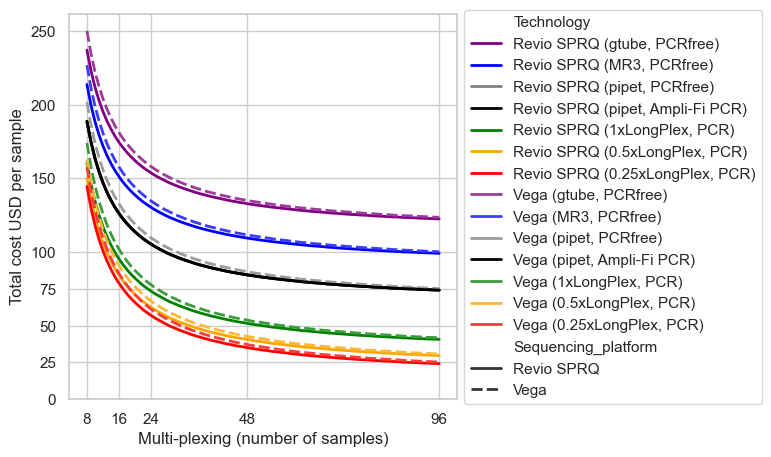

In [32]:
#plotting
fig, ax=plt.subplots(figsize=(5,5))
Fig=sns.lineplot(data=df_sub_2, x="Samples", y="Total_per_sample_v2", hue="Technology", palette=palette, ax=ax, linewidth=2, style="Sequencing_platform")
ax.legend(loc='center left', bbox_to_anchor=(1,0.5))

plt.yticks([0,25, 50, 75, 100, 150, 200, 250]) 
plt.xticks([8,16,24,48,96])
ax.set(
    xlabel='Multi-plexing (number of samples)', 
    ylabel='Total cost USD per sample'
)


plt.savefig('../Figures/Figure1_line_cost_samples_price.png', dpi=600, bbox_inches="tight")

In [33]:
# create a smaller df
# Select only the columns you want to stack
stacked_columns=[
    'DNA_extraction',
    'DNA_shearing_price_per_sample',
    'PCR_mastermix_price_per_rxn',
    'PB_libprep_per_sample',
    'Qiagen_cleanup',
    'seq_price_per_sample',
]

In [34]:
# subsample only the large numbers
sample_values2=[16,48,96]
df_sub_v2=df_sub.loc[df["Samples"].isin(sample_values2)]
df_sub_v2.head()

#16 plex
sample_values16=[16]
df_sub_16=df_sub.loc[df["Samples"].isin(sample_values16)]
df_sub_16.head()

#48 plex
sample_values48=[48]
df_sub_48=df_sub.loc[df["Samples"].isin(sample_values48)]

#96 plex
sample_values96=[96]
df_sub_96=df_sub.loc[df["Samples"].isin(sample_values96)]

In [35]:
df_sub_v2.head()

,Samples,plex,Technology,liquidhandling_required,dilution,tech_dil,DNA_extraction,DNA_shearing_price_per_sample,method,PCR_mastermix,...,PB_libprep_per_sample,Qiagen_cleanup,Technology.1,Sequencing_platform,sequencing_price_per_run,seq_price_per_sample,Total_per_sample_v2,Total_per_run,Total_per_sample_v3,Total_per_run_v3
15,16,16 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,0.39,PB,Revio SPRQ,995,62.2,174.64,2794.3,174.64,2794.24
47,48,48 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,0.13,PB,Revio SPRQ,995,20.7,132.88,6378.3,132.88,6378.24
95,96,96 plex,"Revio SPRQ (gtube, PCRfree)",no,NaN,PCRfree,7.65,48.4,gtube,NaN,...,56.0,0.07,PB,Revio SPRQ,995,10.4,122.52,11761.5,122.52,11761.92
111,16,16 plex,"Revio SPRQ (MR3, PCRfree)",no,NaN,PCRfree,7.65,25.0,MR3,NaN,...,56.0,0.39,PB,Revio SPRQ,995,62.2,151.24,2419.9,151.24,2419.84
143,48,48 plex,"Revio SPRQ (MR3, PCRfree)",no,NaN,PCRfree,7.65,25.0,MR3,NaN,...,56.0,0.13,PB,Revio SPRQ,995,20.7,109.48,5255.1,109.48,5255.04


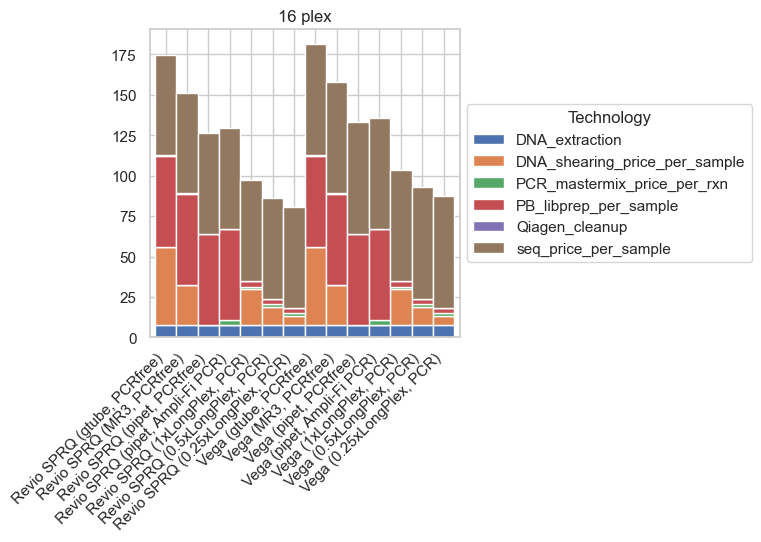

In [37]:
# Plot cost breakdown for 16 plex
ax = df_sub_16.set_index("Technology")[stacked_columns].plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    width=1
)
plt.title('16 plex')
ax.legend(loc='center left', bbox_to_anchor=(1,0.5), title="Technology")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
#ax.legend_.remove()
plt.savefig('../Figures/Supp_cost_16plex.png', dpi=600, bbox_inches="tight")

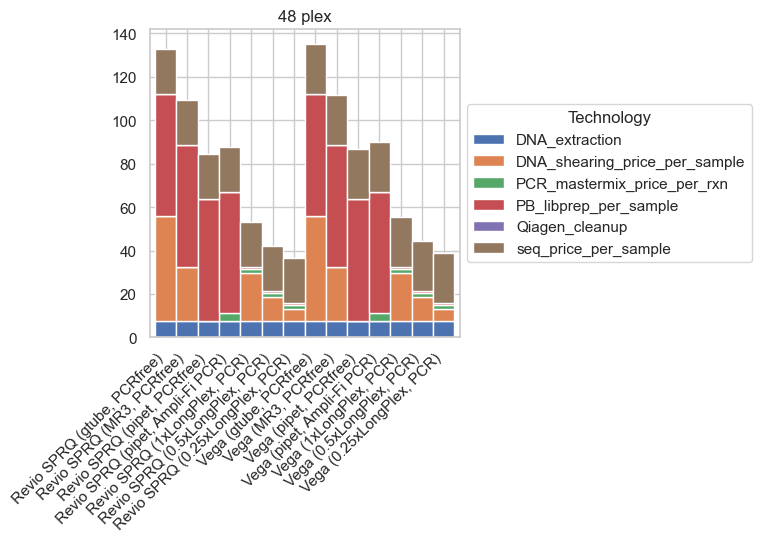

In [38]:
# Plot cost breakdown for 48 plex
ax = df_sub_48.set_index("Technology")[stacked_columns].plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    width=1
)
plt.title('48 plex')
ax.legend(loc='center left', bbox_to_anchor=(1,0.5), title="Technology")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
#ax.legend_.remove()
plt.savefig('../Figures/Supp_cost_48plex.png', dpi=600, bbox_inches="tight")

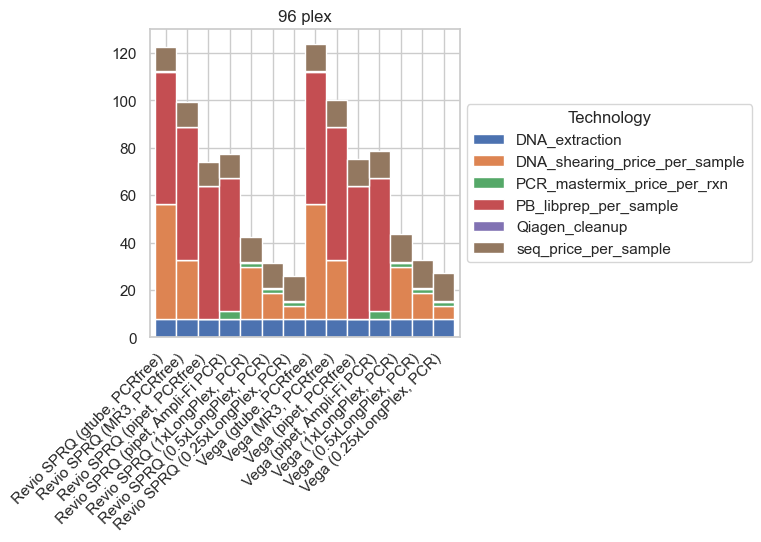

In [39]:
# Plot cost breakdown for 96 plex
ax = df_sub_96.set_index("Technology")[stacked_columns].plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    width=1
)
plt.title('96 plex')
ax.legend(loc='center left', bbox_to_anchor=(1,0.5), title="Technology")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
#ax.legend_.remove()
plt.savefig('../Figures/Supp_cost_96plex.png', dpi=600, bbox_inches="tight")